In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))
from evaluation.plot_attention_patterns import (
    load_all_maps, load_gating, pool_buckets,
    plot_first_token_attention, plot_map, plot_bucket_maps,
    plot_full_grid, plot_gating_distribution,
)

## Attention pattern analysis
All 4 pretrained models: **full**, **gated**, **off-by-one**, **sink**.

Capture is averaged into 10 Rouge-L buckets (`00-01` … `09-10`) aggregated across all
repetition buckets. Each file holds a full causal map `[L, H, S, S]` (query × key),
`S = prefix + suffix - 1`. Maps are raw (not renormalized): attention to the first token
is column 0, and the virtual-sink mass of sink/obo models is `1 - row sum`.

- Prefix / suffix: 50 / 50 tokens
- Models with missing files are skipped automatically.

---
## Setup
Paths, model list, and capture parameters, then load the bucketed `attn_scores` maps.

In [12]:
EXP_BASE = '../results/mem-results/SparseGutenberg'

MODELS = {
    'full':  'llama3-1b-full-attn-fineweb40B-gutenberg3B',
    'gated': 'llama3-1b-gated-attn-fineweb40B-gutenberg3B',
    'obo':   'llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B-te215',
    'sink':  'llama3-1b-sink-attn-fineweb40B-gutenberg3B-te215',
}

OFFSET, PREFIX_LEN, SUFFIX_LEN = 0, 50, 50

In [13]:
# Full causal attention maps, per model, all Rouge-L buckets ({} = no files yet)
attn = {
    key: load_all_maps(EXP_BASE, name, 'attn_scores', OFFSET, PREFIX_LEN, SUFFIX_LEN)
    for key, name in MODELS.items()
}

print('attn_scores availability per model:')
for key, buckets in attn.items():
    n = sum(int(v['count']) for v in buckets.values())
    print(f'  {key:6s}: {len(buckets)}/10 buckets, {n} samples total')

attn_scores availability per model:
  full  : 10/10 buckets, 6600 samples total
  gated : 10/10 buckets, 6600 samples total
  obo   : 10/10 buckets, 6600 samples total
  sink  : 10/10 buckets, 6600 samples total


---
## Experiment 1 — Attention sinks
Mean attention to the **first token** (key position 0) per layer, averaged over heads,
query positions and all samples (Rouge-L buckets pooled). One line per model.

Note: early query rows see very few keys, so they inflate attention to key 0. Pass
`query_slice=slice(PREFIX_LEN, None)` to restrict to decode rows and remove that boundary
effect.

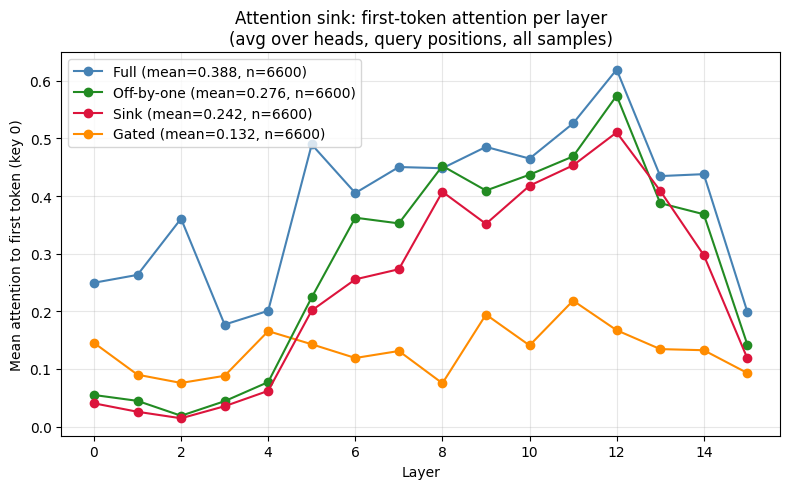

In [16]:
plot_first_token_attention(attn)
plt.show()

---
## Experiment 2 — Attention maps: high vs low memorization
For a chosen `layer` / `head`, one heatmap per mechanism (query × key, log scale).
Pick a Rouge-L bucket: `'09-10'` = strongly memorized, `'00-01'` = not memorized.
`n=` in each panel title is how many samples landed in that bucket.

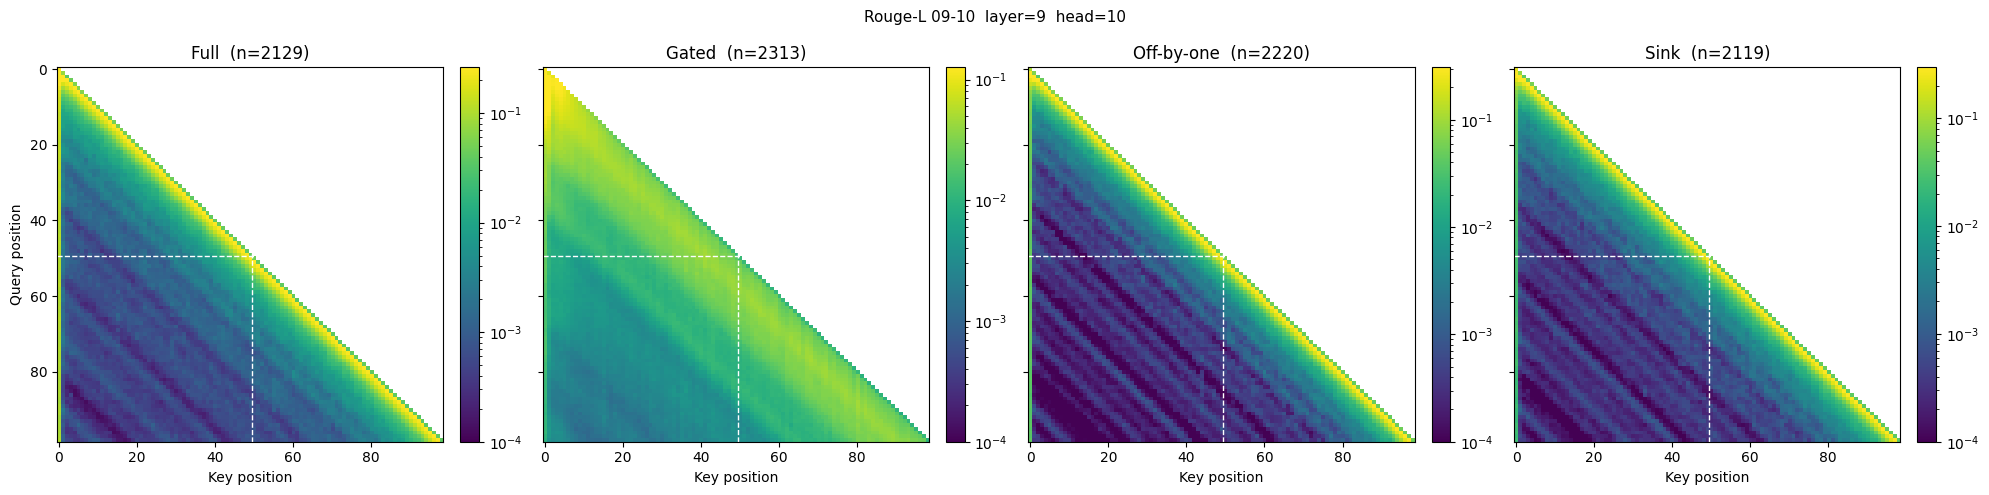

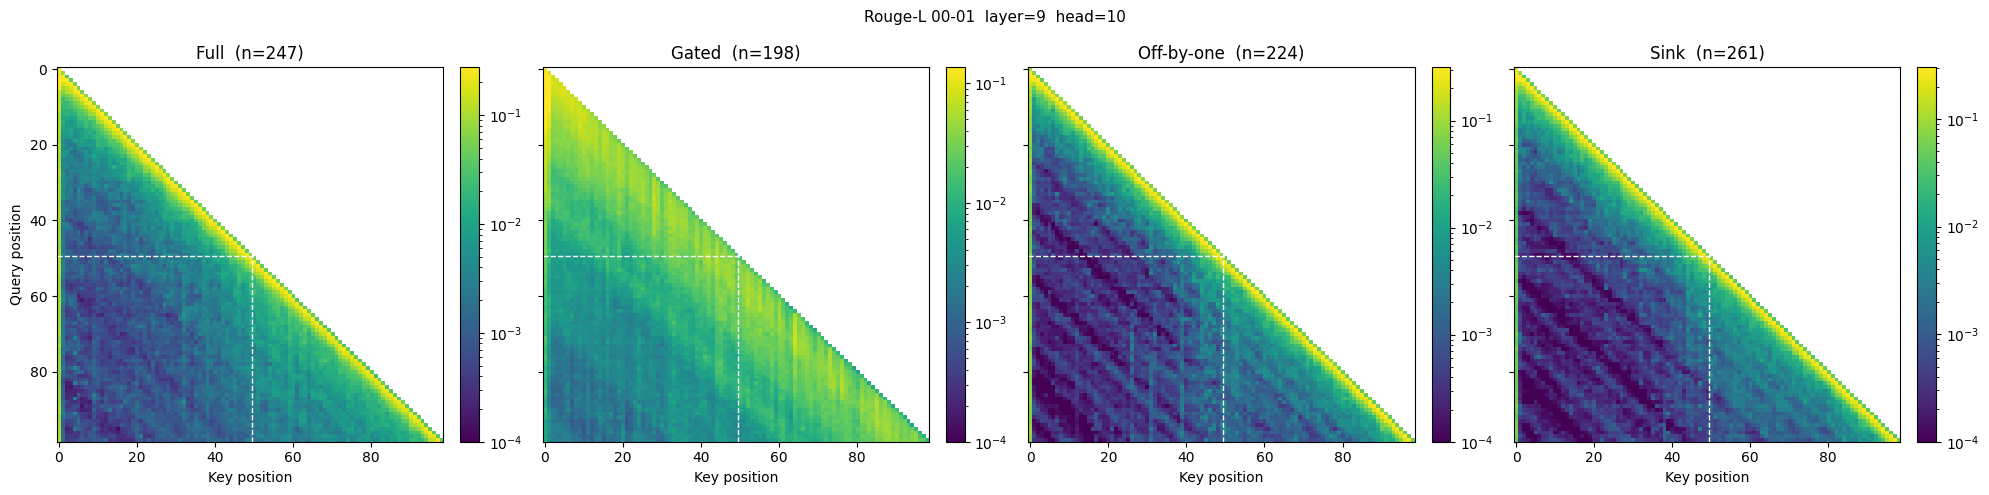

In [72]:
# strongly memorized
LAYER=9
# 10, 20
HEAD=10
plot_bucket_maps(attn, bucket='09-10', layer=LAYER, head=HEAD)
plot_bucket_maps(attn, bucket='00-01', layer=LAYER, head=HEAD)
plt.show()

---
## Experiment 3 — Gating-score distribution (gated model)
Normalized density of the output-gate value `sigmoid(gate)`, pooled over **all layers,
heads, positions and samples**, one curve per Rouge-L bucket — does the gated model gate
differently for memorized vs non-memorized text? (Gated model only.)

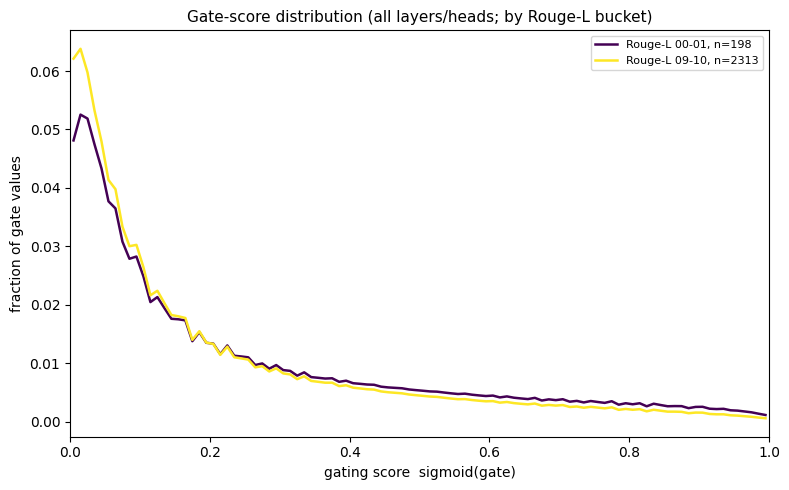

In [75]:
gating = load_gating(EXP_BASE, MODELS['gated'], OFFSET, PREFIX_LEN, SUFFIX_LEN)

# all 10 Rouge-L buckets as a memorization gradient
plot_gating_distribution(gating, buckets=[0, 9])
plt.show()